In [6]:
!pip install yellowbrick
import os
os.environ["OMP_NUM_THREADS"] = '2'
import numpy as np 
import pandas as pd
import pickle
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from IPython.display import display
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Defaulting to user installation because normal site-packages is not writeable


In [7]:
# Use relative paths to reach the processed data folder
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')

print(f"Ready for clustering with {X_train_scaled.shape[1]} features.")

Ready for clustering with 39 features.


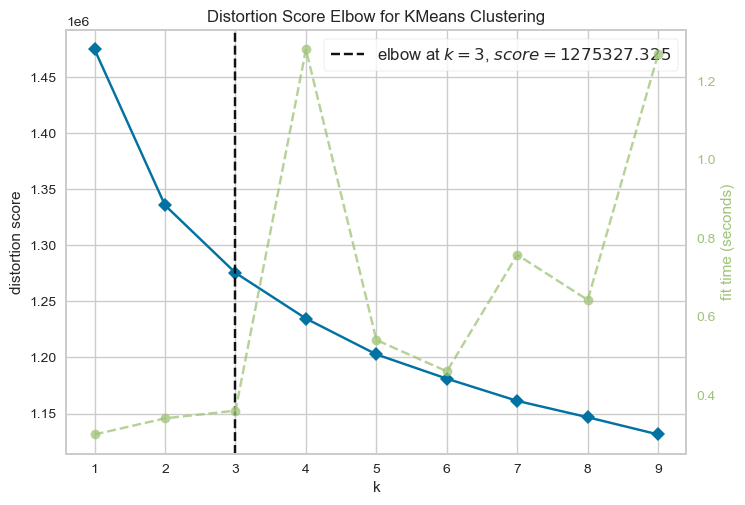

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [8]:
# Create the visualizer
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,10))

# Fit using our updated variable name
visualizer.fit(X_train_scaled) 
visualizer.poof()

In [9]:
# 1. Define the 19 features your Dashboard/XGBoost actually use
clinical_features = [
    'Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c'
]

# 2. Filter your training data to ONLY these 19
# Assuming 'X_train_scaled' is your scaled dataframe
X_train_clinical = X_train_scaled[clinical_features]

# 3. Re-fit K-Means on the 19-feature set
kmeans_19 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_19.fit(X_train_clinical)

# 4. Save this new version to your artifacts
os.makedirs('../artifacts', exist_ok=True)
joblib.dump(kmeans_19, '../artifacts/kmeans_model.pkl')

print("Success: K-Means is now a 19-feature model.")

Success: K-Means is now a 19-feature model.


 The transpose dataset preview (df.head().T) confirms that each record represents a record with demographic , lifestyle and clinical health attributes
relevant to diabetes rsik analysis . Key variables such as age,BMI ,blood pressure,fasting glucose ,HbA1c,physical activity ,diet score
noticeable variation across patients.
#Several patients display elevated fasting glucose and HbA1c values, indicating the presence of individuals at high risk of diabetes or already classified as Type 2 diabetes.
#K-Means clustering k=3 was applied to assign each patient to one to three distinct clusters , enabling further profiling of lifestyle -based diabeted risk groups

In [10]:
# Load the unscaled data to see real clinical values
X_train = pd.read_csv('../data/processed/X_train.csv')

# Attach the clusters we just generated
X_train['Cluster'] = clusters

# Display descriptive statistics for each cluster to see what they represent
cluster_summary = X_train.groupby('Cluster').describe().T
display(cluster_summary)

NameError: name 'clusters' is not defined

In [ ]:
# 1. Identify the actual column names in your dataframe
all_cols = X_train.columns.tolist()

# 2. Find the best matches for our clinical indicators
# We look for partial matches to avoid naming errors
target_features = []
keywords = ['age', 'bmi', 'hba1c', 'glucose', 'smoking']

for key in keywords:
    match = [c for c in all_cols if key in c.lower()]
    if match:
        target_features.append(match[0])

print(f"Profiling based on these columns: {target_features}")

# 3. Calculate the mean values per cluster
cluster_profile = X_train.groupby("Cluster")[target_features].mean()

# 4. Add the count of patients
cluster_profile['Patient_Count'] = X_train['Cluster'].value_counts()

display(cluster_profile)

The data is split into three clusters . Cluster 0 represents low-risk individuals with better life style habits and lower glucose levels.Cluster 1 represents high-risk inviduals with higher age , BMI , glucose and diabetes prevelance . Cluster 2 is a moderate risk group with mixed health indicators.Cluster 2 is in the middle with moderate values for most indicators but a higher BMI than cluster 0 and lower risk than cluster 1 
. Overall , the clusters clearly seperate low,meduim and high diabetes risk profiles.

In [ ]:
# 1. Select the most descriptive clinical and lifestyle features from your list
clinical_features = [
    'Age', 
    'bmi', 
    'hba1c', 
    'glucose_fasting', 
    'physical_activity_minutes_per_week', 
    'diet_score',
    'alcohol_consumption_per_week'
]

# 2. Calculate the mean values per cluster
cluster_profile = X_train.groupby("Cluster")[clinical_features].mean()

# 3. Add the count of patients in each group
cluster_profile['patient_count'] = X_train['Cluster'].value_counts()

# 4. Sort by HbA1c so you can easily identify the "High Risk" group
display(cluster_profile.sort_values(by='hba1c', ascending=False))

The scatter plot show clear seperation mainly by fasting glucose . cluster 1 (blue) has the highest glucose value (high-risk group) ,Cluster 0 (red) has the lowest glucose values(low-risk group) , and Cluster 2(green) falls in between (moderate risk) . Physical activity overlaps across clusters ,meaning glucose is the strongest factor driving the segmentation 

In [ ]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train.columns output
sns.scatterplot(
    data=X_train,
    x="physical_activity_minutes_per_week", 
    y="glucose_fasting", 
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Physical Activity (minutes/week)")
plt.ylabel("Fasting Glucose")
plt.title("Physical Activity vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

BMI and glucose fasting show a strong cluster seperation . Mainly low BMI/low glucose , Cluster 2 moderate glucose with higher BMI , and Cluster 1 contains the highest glucose values across BMI ranges , indicating the highest-risk group.

In [ ]:
plt.figure(figsize=(8, 5))

# Using the exact names from your X_train output
sns.scatterplot(
    data=X_train,
    x="sleep_hours_per_day",
    y="glucose_fasting",
    hue="Cluster",
    palette="viridis"
)

plt.xlabel("Sleep (hours/day)")
plt.ylabel("Fasting Glucose")
plt.title("Sleep vs. Fasting Glucose by Cluster")
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

Fasting glucose clearly seperates the clusters , while sleep hours overlap across all groups. Cluster 1 shows shows consistently higher glucose (high-risk),Cluster 0 lower glucose (low-risk),and Cluster 2 moderate levels . This suggests that sleep is not strong clustering factor compared to glucose

In [ ]:
from sklearn.decomposition import PCA

# 1. Apply PCA to the scaled features (use the variable from our earlier cells)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled.drop(columns=['Cluster']))

# 2. Create dataframe for plotting
pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["Cluster"] = X_train_scaled["Cluster"].values

# 3. Plot PCA scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Cluster", 
    palette="viridis", 
    alpha=0.6
)

plt.title("PCA Visualization: Mathematical Separation of Lifestyle Clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
# The variance labels tell you how much 'information' from the 16 features is captured in each axis
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

The PCA scatter plot reduces the multi-dimensional dataset into two principal componenets PC1 and PC2 to make the clusters in two dimension . The plot shows three clearly seperated groups , confirming that K- means sucessfully segmented the patients into three distinct lifestyle/clinical risk profiles.Cluster0(red) is seperated on the left side lower(PC1) , indicating a distinct patient group with similar characteristics . 
Cluster1(blue) appears on the right side(higher PC1 values) , showing another clearly diffirent patient segment .Cluster2 (green) is concentrated towards the buttom (lower PC2 values ), forming a third unique group